In [ ]:
import pandas as pd
import re
import numpy as np

#MEMUAT DATASET & INISIALISASI
#Memuat data asli manusia dan hasil sintesis AI untuk proses penyeimbangan.

df_human = pd.read_csv('../data/interim/dataset_human_pre2018_cleaned_tahap1_7_fix.csv')
df_ai    = pd.read_csv('../data/interim/dataset_ai_synthesized_final_9_fix.csv')

len_human_awal = len(df_human)
len_ai_awal    = len(df_ai)

print("Memulai Preprocessing Tahap 2")
print(f"Distribusi awal: Manusia = {len_human_awal} | AI = {len_ai_awal}")

#PEMROSESAN TEKS LANJUTAN (GENERAL PREPROCESSING)
#Menyeragamkan format teks menjadi huruf kecil (case folding) dan 
#membersihkan karakter spesifik yang tidak relevan.

def general_preprocessing(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s\.,\?\!\-\(\)]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Menerapkan general preprocessing pada kedua kelas data...")
df_human['abstract'] = df_human['abstract'].apply(general_preprocessing)
df_ai['abstract']    = df_ai['abstract'].apply(general_preprocessing)

#PEMBERSIHAN ARTEFAK SINTESIS AI (IndoT5)
#Menghilangkan noise/artefak spesifik hasil generasi model bahasa.

def clean_ai_artifacts(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'\(?teks dengan relevansi[^\)]*\)?', '', text, flags=re.IGNORECASE)
    text = re.sub(r'^\(\d+\)\s*', '', text)
    text = re.sub(r'\(\s*\)', '', text)
    text = re.sub(r'\b(?:dll|dsb|dkk)\s*[,.]\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'-\s*-+', '-', text)
    text = re.sub(r'\s+([,.\?\!\;\:])', r'\1', text)
    text = re.sub(r',(\s*,)+', ',', text)  
    text = re.sub(r',\s*\.', '.', text)   
    text = re.sub(r'\.\s*,', '.', text)   
    text = re.sub(r'\.\s*\.+', '.', text) 
    text = re.sub(r'\b(\w+)(\s+\1){2,}\b', r'\1', text)
    
    #Menghapus anomali angka dan kurung pasca-titik akhir
    text = re.sub(r'(\.\s*)(?:[\(\)\d\-\s\.]+)$', r'\1', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Membersihkan artefak generasi pada kelas AI...")
df_ai['abstract_sebelum_bersih'] = df_ai['abstract']
df_ai['abstract'] = df_ai['abstract'].apply(clean_ai_artifacts)

#Melacak abstrak yang mengalami perubahan signifikan akibat artefak
df_ai['clean_no_space'] = df_ai['abstract'].str.replace(' ', '')
df_ai['seb_no_space']   = df_ai['abstract_sebelum_bersih'].str.replace(' ', '')
df_ai_berubah_nyata = df_ai[df_ai['clean_no_space'] != df_ai['seb_no_space']]

print(f"-> Teridentifikasi {len(df_ai_berubah_nyata)} dokumen AI dengan indikasi artefak mesin.")

#Menampilkan sampel bukti pembersihan artefak
df_ai['diff_len'] = df_ai['abstract_sebelum_bersih'].str.len() - df_ai['abstract'].str.len()
contoh_jelas = df_ai[df_ai['diff_len'] > 10].head(1)

for i, (_, row) in enumerate(contoh_jelas.iterrows(), 1):
    awal = row['abstract_sebelum_bersih'][-150:]
    akhir = row['abstract'][-150:]
    print(f"-> Sampel Pembersihan (Akhir Teks):\n   [SEBELUM] ...{awal}\n   [SESUDAH] ...{akhir}\n")

#Membersihkan kolom pelacakan
df_ai = df_ai.drop(columns=['clean_no_space', 'seb_no_space', 'abstract_sebelum_bersih', 'diff_len'])

#Eliminasi teks AI yang tidak memenuhi syarat kepanjangan minimal
len_ai_sebelum_filter = len(df_ai)
df_ai['word_count'] = df_ai['abstract'].apply(lambda x: len(x.split()))
df_ai = df_ai[df_ai['word_count'] >= 40].copy()
df_ai = df_ai.drop_duplicates(subset=['abstract']).copy()
ai_terbuang_filter = len_ai_sebelum_filter - len(df_ai)
print(f"Eliminasi teks AI tidak valid (pendek/duplikat): {ai_terbuang_filter} dokumen dihapus.")

#PEMOTONGAN TEKS (TRUNCATION)
#Menyeragamkan maksimal kepanjangan dokumen menjadi 100 kata untuk 
#mencegah bias analisis berdasakan dimensi panjang teks.

def truncate_to_100_words(text):
    words = str(text).split()
    if len(words) > 100:
        return ' '.join(words[:100])
    return str(text)

print("Menerapkan pemotongan batas maksimal (truncate) 100 kata pada dataset...")
df_human['abstract_sebelum_truncate'] = df_human['abstract']
df_ai['abstract_sebelum_truncate'] = df_ai['abstract']

df_human['abstract'] = df_human['abstract'].apply(truncate_to_100_words)
df_ai['abstract'] = df_ai['abstract'].apply(truncate_to_100_words)

#Melacak jumlah dokumen yang terpotong
mask_truncate_human = df_human['abstract_sebelum_truncate'] != df_human['abstract']
df_human_truncate = df_human[mask_truncate_human]

mask_truncate_ai = df_ai['abstract_sebelum_truncate'] != df_ai['abstract']
df_ai_truncate = df_ai[mask_truncate_ai]

print(f"-> Total terpotong (Manusia) : {len(df_human_truncate)} dokumen.")
print(f"-> Total terpotong (AI)      : {len(df_ai_truncate)} dokumen.")

df_human = df_human.drop(columns=['abstract_sebelum_truncate'])
df_ai = df_ai.drop(columns=['abstract_sebelum_truncate', 'word_count'])

#PENYEIMBANGAN KELAS (UNDERSAMPLING)
#Mengurangi sampel pada kelas mayoritas agar seimbang dengan kelas minoritas.

min_size = min(len(df_human), len(df_ai))
print(f"Menyeimbangkan proporsi dataset menjadi {min_size} sampel per kelas...")

df_human_final = df_human.sample(n=min_size, random_state=42).copy()
df_ai_final    = df_ai.sample(n=min_size, random_state=42).copy()

human_terbuang = df_human[~df_human.index.isin(df_human_final.index)]
human_terbuang_under = len(human_terbuang)
ai_terbuang_under    = len(df_ai) - min_size

if human_terbuang_under > 0:
    print(f"-> Mengeksekusi undersampling: {human_terbuang_under} sampel kelas manusia dieliminasi.")

df_human_final['label'] = 'human'
df_ai_final['label'] = 'ai'

#Penggabungan akhir dan pengacakan susunan data (shuffling)
df_final = pd.concat([df_human_final, df_ai_final], ignore_index=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

df_final = df_final[['source', 'year', 'abstract', 'label']]
df_final.to_csv('../data/processed/final_dataset_detector_v1_12_fix.csv', index=False)


#REKAPITULASI PEMROSESAN

print("\nREKAPITULASI PENYUSUTAN DATA")
print("-" * 65)
print(f"{'Tahapan':<30} | {'Manusia':<8} | {'AI':<8} | {'Total':<8}")
print("-" * 65)
print(f"{'Jumlah Data Awal':<30} | {len_human_awal:<8} | {len_ai_awal:<8} | {len_human_awal+len_ai_awal:<8}")
print(f"{'Filter Artefak & Invalid':<30} | 0        | -{ai_terbuang_filter:<7} | -{ai_terbuang_filter:<7}")
print(f"{'Undersampling':<30} | -{human_terbuang_under:<7} | -{ai_terbuang_under:<7} | -{human_terbuang_under+ai_terbuang_under:<7}")
print("-" * 65)
print(f"{'Jumlah Data Final':<30} | {len(df_human_final):<8} | {len(df_ai_final):<8} | {len(df_final):<8}")
print("-" * 65)

df_final['word_count'] = df_final['abstract'].apply(lambda x: len(str(x).split()))
print(f"\nStatistik panjang karakter dokumen per kelas:\n{df_final.groupby('label')['word_count'].describe()}")

Memulai Preprocessing Tahap 2
Distribusi awal: Manusia = 1138 | AI = 1138
Menerapkan general preprocessing pada kedua kelas data...
Membersihkan artefak generasi pada kelas AI...
-> Teridentifikasi 713 dokumen AI dengan indikasi artefak mesin.
-> Sampel Pembersihan (Akhir Teks):
   [SEBELUM] ...erhitungannya sendiri. (teks dengan relevansi eea) (ahp). keputusan sistem pendukung keputusan (s). masyarakat yang sesuai dengan tujuan tersebut (c).
   [SESUDAH] ...tuk menyederhanakan proses perhitungannya sendiri. (ahp). keputusan sistem pendukung keputusan (s). masyarakat yang sesuai dengan tujuan tersebut (c).

Eliminasi teks AI tidak valid (pendek/duplikat): 1 dokumen dihapus.
Menerapkan pemotongan batas maksimal (truncate) 100 kata pada dataset...
-> Total terpotong (Manusia) : 1036 dokumen.
-> Total terpotong (AI)      : 328 dokumen.
Menyeimbangkan proporsi dataset menjadi 1137 sampel per kelas...
-> Mengeksekusi undersampling: 1 sampel kelas manusia dieliminasi.

REKAPITULASI PENYUSUTA

STATISTIK ASLI ABSTRAK MANUSIA (SEBELUM TRUNCATE)
count    1138.000000
mean      157.177504
std        45.581266
min        52.000000
25%       126.000000
50%       153.000000
75%       187.000000
max       416.000000
Name: word_count, dtype: float64


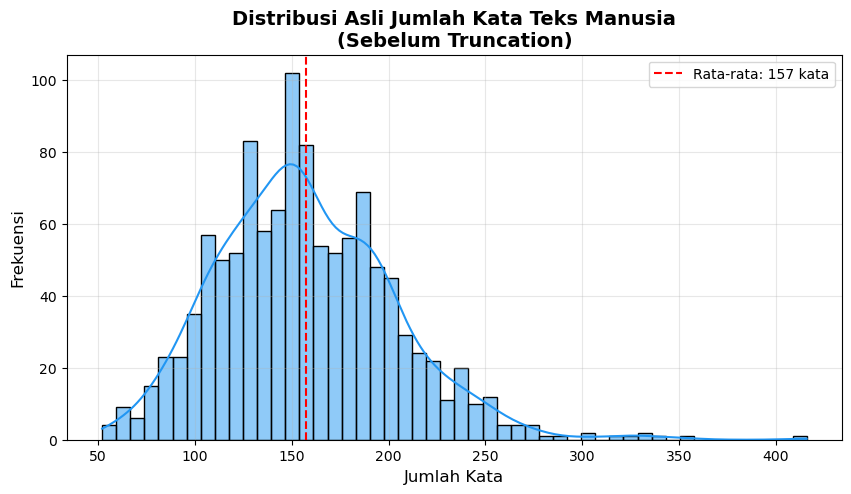

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data asli manusia SEBELUM di-truncate
df_human_asli = pd.read_csv('../data/interim/dataset_human_pre2018_cleaned_tahap1_7_fix.csv')

# 2. Hitung jumlah kata murni
df_human_asli['word_count'] = df_human_asli['abstract'].apply(lambda x: len(str(x).split()))

# 3. Tampilkan statistik deskriptif
print("="*50)
print("STATISTIK ASLI ABSTRAK MANUSIA (SEBELUM TRUNCATE)")
print("="*50)
print(df_human_asli['word_count'].describe())
print("="*50)

# 4. Buat visualisasi distribusinya
plt.figure(figsize=(10, 5))
sns.histplot(df_human_asli['word_count'], bins=50, kde=True, color='#2196F3')
plt.axvline(df_human_asli['word_count'].mean(), color='red', linestyle='--', label=f"Rata-rata: {df_human_asli['word_count'].mean():.0f} kata")
plt.title('Distribusi Asli Jumlah Kata Teks Manusia\n(Sebelum Truncation)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Kata', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

STATISTIK ABSTRAK AI (SEBELUM TRUNCATE)
count    1138.000000
mean       92.978032
std        23.819507
min        35.000000
25%        75.000000
50%        90.500000
75%       109.000000
max       169.000000
Name: word_count, dtype: float64


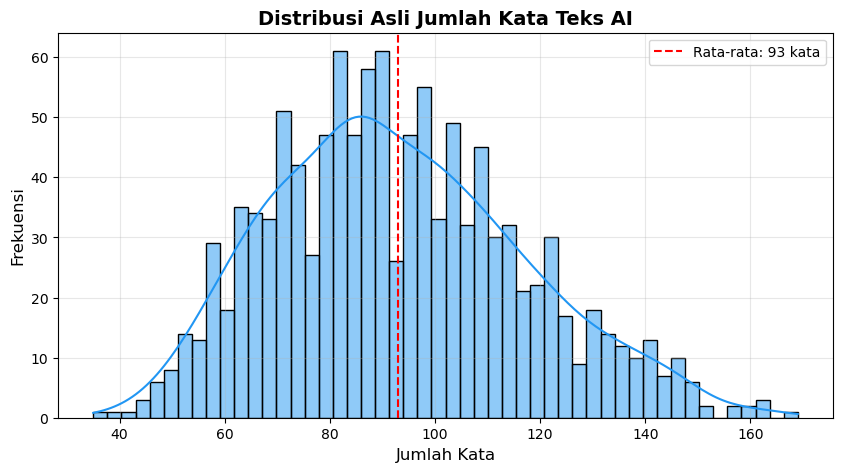

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data asli manusia SEBELUM di-truncate
df_human_asli = pd.read_csv('../data/interim/dataset_ai_synthesized_final_9_fix.csv')

# 2. Hitung jumlah kata murni
df_human_asli['word_count'] = df_human_asli['abstract'].apply(lambda x: len(str(x).split()))

# 3. Tampilkan statistik deskriptif
print("="*50)
print("STATISTIK ABSTRAK AI (SEBELUM TRUNCATE)")
print("="*50)
print(df_human_asli['word_count'].describe())
print("="*50)

# 4. Buat visualisasi distribusinya
plt.figure(figsize=(10, 5))
sns.histplot(df_human_asli['word_count'], bins=50, kde=True, color='#2196F3')
plt.axvline(df_human_asli['word_count'].mean(), color='red', linestyle='--', label=f"Rata-rata: {df_human_asli['word_count'].mean():.0f} kata")
plt.title('Distribusi Asli Jumlah Kata Teks AI', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Kata', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [4]:
import pandas as pd
import textwrap

# Load ulang data awal (sebelum diapa-apain) untuk kita intip
df_h_intip = pd.read_csv('../data/interim/dataset_human_pre2018_cleaned_tahap1_7_fix.csv')
df_a_intip = pd.read_csv('../data/interim/dataset_ai_synthesized_final_9_fix.csv')

# Fungsi potong 100 kata
def get_truncated_text(text):
    words = str(text).split()
    if len(words) > 100:
        return ' '.join(words[:100]) + " ... [DIPOTONG]"
    return str(text)

def get_word_count(text):
    return len(str(text).split())

df_h_intip['word_count_asli'] = df_h_intip['abstract'].apply(get_word_count)
df_a_intip['word_count_asli'] = df_a_intip['abstract'].apply(get_word_count)

# Ambil HANYA data yang panjang aslinya > 100 kata agar kelihatan efek potongnya
sampel_human = df_h_intip[df_h_intip['word_count_asli'] > 120].head(2)
sampel_ai = df_a_intip[df_a_intip['word_count_asli'] > 120].head(2)

def print_comparison(label, df_sampel):
    print("="*80)
    print(f"INSPEKSI EFEK TRUNCATE PADA TEKS {label.upper()}")
    print("="*80)
    
    for i, (_, row) in enumerate(df_sampel.iterrows(), 1):
        teks_asli = str(row['abstract'])
        teks_potong = get_truncated_text(teks_asli)
        
        print(f"\n[{label.upper()} - SAMPEL {i}] (Panjang Asli: {row['word_count_asli']} kata)")
        print("-" * 50)
        print("TEKS ASLI (Full):")
        print(textwrap.fill(teks_asli, width=80))
        print("-" * 50)
        print("TEKS SETELAH DI-TRUNCATE (100 Kata):")
        print(textwrap.fill(teks_potong, width=80))

print_comparison("Manusia", sampel_human)
print_comparison("AI (IndoT5)", sampel_ai)

INSPEKSI EFEK TRUNCATE PADA TEKS MANUSIA

[MANUSIA - SAMPEL 1] (Panjang Asli: 182 kata)
--------------------------------------------------
TEKS ASLI (Full):
Kemajuan teknologi banyak memberian pengaruh dalam proses pekerjaan dibidang
pertanian, dimana banyak peralatan pertanian yang dikembangkan sehingga proses
pekerjaan pertanian dapat diselesaikan dengan baik dan memberikan hasil yang
lebih baik dari segi kualitas maupun kuantitas. Cabai merupakan salah satu
komuditi agrobisnis pertanian atau perkebunan di indonesia yang banyak diminati
oleh para petani. Hal ini disebabkan makanan di Indonesia pada umumnya banyak
menggunakan cabai, sehingga cabai menjadi komuditi yang sangat menjanjikan bagi
petani. Masalahnya pada saat tanaman cabai terinfeksi oleh penyakit maupun hama
tertentu, sehingga para petani perlu untuk mendiagnosa tanamannya tersebut, maka
bukan saja akan membuat biaya untuk pembelian pestisida yang membengkak akan
tetapi juga dapat mengakibatkan tanaman cabai mati sehingga

STATISTIK SELISIH PANJANG KATA (HUMAN vs AI INDOT5)
count    1138.000000
mean       64.199473
std        29.229263
min        -1.000000
25%        46.000000
50%        59.000000
75%        78.000000
max       276.000000
Name: selisih_kata, dtype: float64
Persentase teks AI yang lebih pendek dari aslinya = 99.74%



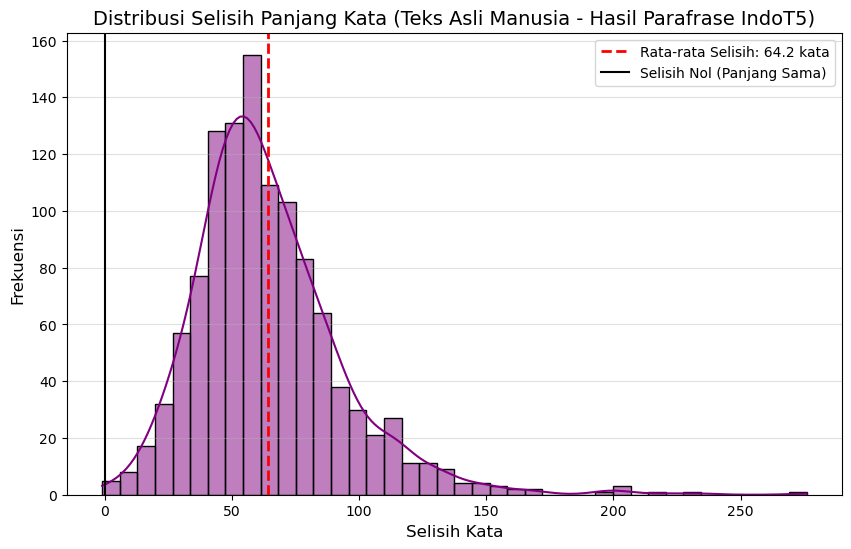


SAMPEL DATA DENGAN SELISIH TERBESAR
     word_count_human  word_count_ai  selisih_kata
102               416            140           276
993               342            108           234
422               353            134           219
257               330            127           203
685               330            130           200


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
# Pastikan nama file ini sesuai dengan dataset asli lu sebelum di-truncate
df_human = pd.read_csv('../data/interim/dataset_human_pre2018_cleaned_tahap1_7_fix.csv')
df_ai = pd.read_csv('../data/interim/dataset_ai_synthesized_final_9_fix.csv')

# 2. Hitung jumlah kata untuk setiap baris
df_human['word_count_human'] = df_human['abstract'].apply(lambda x: len(str(x).split()))
df_ai['word_count_ai'] = df_ai['abstract'].apply(lambda x: len(str(x).split()))

# 3. Gabungkan data berdasarkan indeks (asumsi indeks baris human dan ai bersesuaian)
# Hal ini karena proses parafrase dilakukan baris per baris.
df_compare = pd.concat([df_human['word_count_human'], df_ai['word_count_ai']], axis=1)

# 4. Hitung selisih (Human - AI)
# Nilai positif berarti AI lebih pendek dari Human.
df_compare['selisih_kata'] = df_compare['word_count_human'] - df_compare['word_count_ai']

# 5. Tampilkan statistik selisih
print("="*60)
print("STATISTIK SELISIH PANJANG KATA (HUMAN vs AI INDOT5)")
print("="*60)
print(df_compare['selisih_kata'].describe())
print("="*60)

# Hitung persentase data AI yang lebih pendek dari Human
persentase_lebih_pendek = (df_compare['selisih_kata'] > 0).mean() * 100
print(f"Persentase teks AI yang lebih pendek dari aslinya = {persentase_lebih_pendek:.2f}%\n")

# 6. Visualisasi Distribusi Selisih
plt.figure(figsize=(10, 6))
sns.histplot(df_compare['selisih_kata'], bins=40, kde=True, color='purple')
plt.axvline(df_compare['selisih_kata'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Rata-rata Selisih: {df_compare["selisih_kata"].mean():.1f} kata')
plt.axvline(0, color='black', linestyle='-', linewidth=1.5, label='Selisih Nol (Panjang Sama)')

plt.title('Distribusi Selisih Panjang Kata (Teks Asli Manusia - Hasil Parafrase IndoT5)', fontsize=14)
plt.xlabel('Selisih Kata', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.4)
plt.show()

# 7. Tampilkan beberapa sampel ekstrem
print("\n" + "="*60)
print("SAMPEL DATA DENGAN SELISIH TERBESAR")
print("="*60)
print(df_compare.sort_values(by='selisih_kata', ascending=False).head(5))